In [1]:
import pandas as pd
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Input, Dense, Dropout
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt, seaborn as sns

2026-01-31 14:36:13.982284: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
X_train, X_val = np.linspace(-1, 1, 20).reshape(-1, 1), np.linspace(-1, 1, 20).reshape(-1, 1)

In [5]:
y_train = np.array([-0.6561, -0.3099, -0.59035, -0.50855, -0.285,
                    -0.2443, -0.02445, 0.00135, -0.2006, 0.07475,
                    -0.1422, 0.06515, 0.15265, 0.3521, 0.28415,
                    0.5524, 0.23115, 0.20835, 0.4211, 0.60485]),

y_val = np.array([-0.69415, -0.451, -0.43005, -0.4484, -0.1475,
                -0.5019, -0.28055, 0.24595, -0.21425, -0.0286,
                0.23415, 0.46575, 0.07955, 0.1973, 0.0719,
                0.3639, 0.5536, 0.3365, 0.50705, 0.33435])

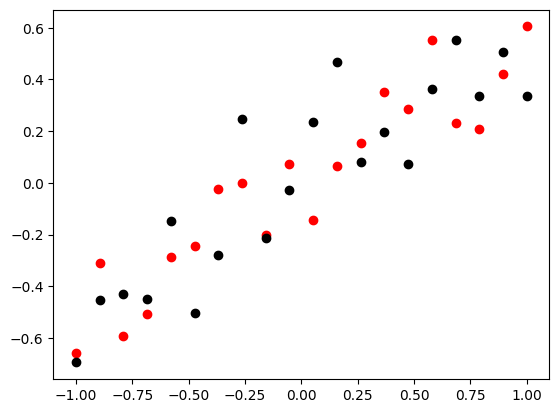

In [6]:
plt.scatter(x=X_train, y=y_train, c='red')
plt.scatter(x=X_val, y=y_val, c='black')
plt.show()

In [7]:
model_without_do = Sequential()

In [8]:
model_without_do.add(Input(shape=(1,)))
model_without_do.add(Dense(128, activation='relu'))
model_without_do.add(Dense(128, activation='relu'))
model_without_do.add(Dense(1, activation='linear'))

In [9]:
model_without_do.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model_without_do.compile(loss='mse', optimizer='Adam', metrics=['mse'])

In [11]:
history = model_without_do.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=500)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.1098 - mse: 0.1098 - val_loss: 0.1003 - val_mse: 0.1003
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0891 - mse: 0.0891 - val_loss: 0.0829 - val_mse: 0.0829
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0721 - mse: 0.0721 - val_loss: 0.0685 - val_mse: 0.0685
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0581 - mse: 0.0581 - val_loss: 0.0571 - val_mse: 0.0571
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0470 - mse: 0.0470 - val_loss: 0.0483 - val_mse: 0.0483
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0384 - mse: 0.0384 - val_loss: 0.0416 - val_mse: 0.0416
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0320 - mse: 0.0320 - val_loss: 0.0368 - val_mse: 0.0368
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0273 - mse: 0.0273 - val_loss: 0.0334 - val_mse: 0.0334
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0241 - mse

In [12]:
history.history.keys()

dict_keys(['loss', 'mse', 'val_loss', 'val_mse'])

In [13]:
y_pred = model_without_do.predict(X_val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


In [14]:
sort_idx = np.argsort(X_val[:,0])
X_val_sorted = X_val[sort_idx]
y_pred_sorted = y_pred[sort_idx]

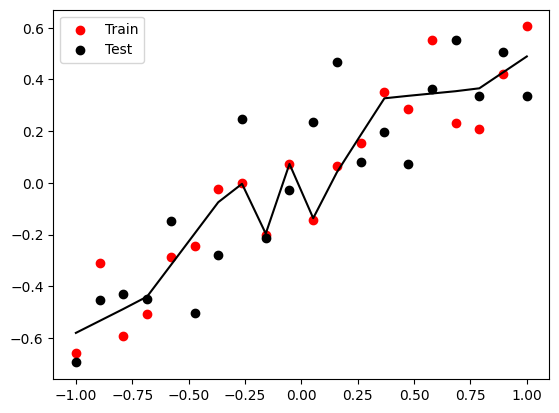

In [15]:
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_val, y_val, c='black', label='Test')
plt.legend()
plt.plot(X_val_sorted, y_pred_sorted, color='black')
plt.show()

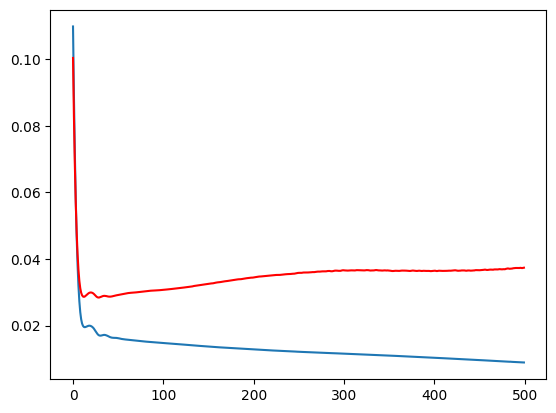

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'], color='red')
plt.show()

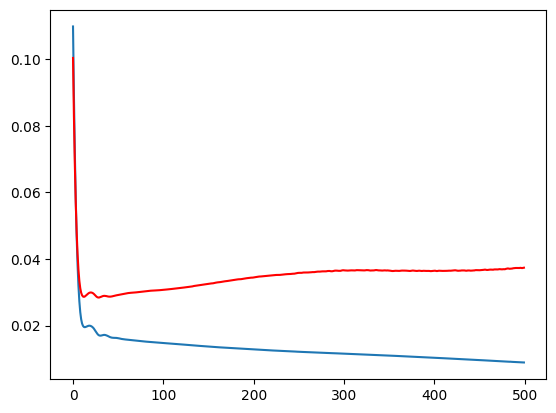

In [17]:
plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'], color='red')
plt.show()

## now with dropouts:

In [34]:
model_with_do = Sequential()

In [35]:
model_with_do.add(Input(shape=(1,)))
model_with_do.add(Dense(128, activation='relu'))
model_with_do.add(Dropout(0.3))
model_with_do.add(Dense(128, activation='relu'))
model_with_do.add(Dropout(0.3))
model_with_do.add(Dense(1, activation='linear'))

In [36]:
model_with_do.compile(loss='mse', optimizer='Adam', metrics=['mse'])

In [37]:
history = model_with_do.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=500)

Epoch 1/500


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1002 - mse: 0.1002 - val_loss: 0.1044 - val_mse: 0.1044
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.1045 - mse: 0.1045 - val_loss: 0.0860 - val_mse: 0.0860
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0890 - mse: 0.0890 - val_loss: 0.0707 - val_mse: 0.0707
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0638 - mse: 0.0638 - val_loss: 0.0584 - val_mse: 0.0584
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0547 - mse: 0.0547 - val_loss: 0.0485 - val_mse: 0.0485
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0350 - mse: 0.0350 - val_loss: 0.0408 - val_mse: 0.0408
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0320 - mse: 0.0320 - val_loss: 0.0353 - val_mse: 0.0353
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0293 - mse: 0.0293 - val_loss: 0.0318 - val_mse: 0.0318
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0249 - mse: 0.0249 - val_

In [43]:
y_pred = model_with_do.predict(X_val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [44]:
sort_idx = np.argsort(X_val[:,0])
X_val_sorted = X_val[sort_idx]
y_pred_sorted = y_pred[sort_idx]

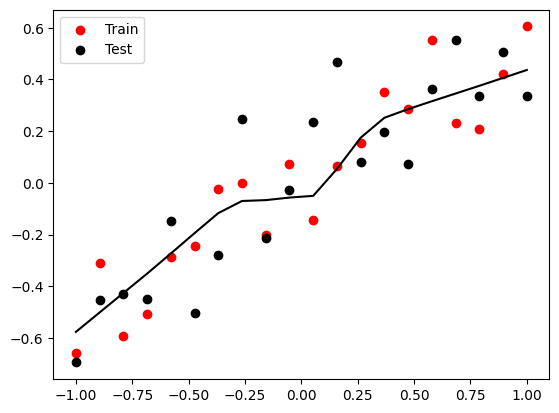

In [45]:
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_val, y_val, c='black', label='Test')
plt.legend()
plt.plot(X_val_sorted, y_pred_sorted, color='black')
plt.show()

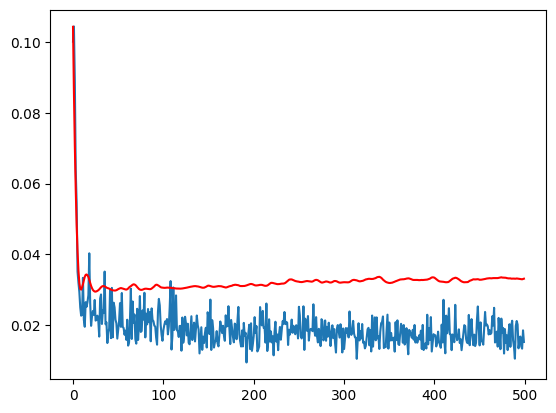

In [46]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'], color='red')
plt.show()

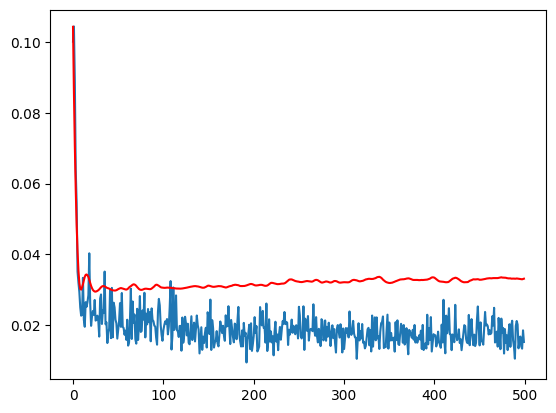

In [47]:
plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'], color='red')
plt.show()